In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from datasets import load_dataset
import numpy as np
torch.set_float32_matmul_precision("high")

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)

    # 1. calculate dot products QK
    attention_scores = torch.matmul(query, key.transpose(-2, -1))

    # 2. scale the scores
    attention_scores = attention_scores / math.sqrt(d_k)
    
    # 3. apply mask if given
    if mask is not None:
        attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))
    
    # 4. apply softmax
    attention_weights = F.softmax(attention_scores, dim=-1)

    # 5. apply dropout
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # 6.  multiply weights by values
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2,x1], dim=-1)

def apply_rope(q, k, cos, sin):
    T = q.shape[-2]
    cos = cos[:T][None, None, :, :].to(q.dtype)
    sin = sin[:T][None, None, :, :].to(q.dtype)
    q = q * cos + rotate_half(q) * sin
    k = k * cos + rotate_half(k) * sin
    return q, k

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, max_seq_len=512, dropout=0.0, rope_base=10000.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert self.head_dim % 2 == 0

        self.W_qkv = nn.Linear(d_model, 3 * d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        inv_freq = 1.0 / (rope_base ** (torch.arange(0, self.head_dim, 2).float() / self.head_dim))
        t = torch.arange(max_seq_len).float()
        freqs = torch.outer(t, inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer("rope_cos", emb.cos(), persistent=False)
        self.register_buffer("rope_sin", emb.sin(), persistent=False)

    def split_heads(self, x):
        B, L, D = x.size()
        x = x.view(B, L, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)
        return x
    
    def combine_heads(self, x):
        B, H, L, Hd = x.size()
        x = x.transpose(1,2).contiguous()
        x = x.view(B, L, H * Hd)
        return x
    
    def forward(self, x, mask=None):
        qkv = self.W_qkv(x)
        Q, K, V = qkv.chunk(3, dim=-1)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        if mask is not None and mask.dim() == 3:
            mask = mask.unsqueeze(1)
        
        attn_output = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=mask,
            dropout_p=self.dropout.p if self.training else 0.0,
        )
        attn_weights = None
        attn_output = self.combine_heads(attn_output)
        attn_output = self.W_o(attn_output)
        attn_output = self.dropout(attn_output)

        return attn_output, attn_weights

class SwiGLUFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)
        self.w_up   = nn.Linear(d_model, d_ff, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        gate = F.silu(self.w_gate(x))   # gating signal
        up   = self.w_up(x)             # value path
        x    = gate * up                # elementwise gating
        x    = self.dropout(x)
        x    = self.w_down(x)
        return x

# position-wise feed forward network
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x
    
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        in_dtype = x.dtype
        x_fp32 = x.float()
        mean_sq = x_fp32.pow(2).mean(dim=-1, keepdim=True)
        x_fp32 = x_fp32 * torch.rsqrt(mean_sq + self.eps)
        return (x_fp32.to(in_dtype)) * self.weight
    
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, max_seq_len, dropout)
        self.feed_forward = SwiGLUFeedForward(d_model, d_ff, dropout)

        self.norm1 = RMSNorm(d_model)
        self.norm3 = RMSNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, tgt_mask=None):
        self_attn_input = self.norm1(x)
        self_attn_output, _ = self.self_attn(
            x=self_attn_input,
            mask=tgt_mask
        )
        x = x + self.dropout1(self_attn_output)

        ff_output = self.feed_forward(self.norm3(x))
        x = x + self.dropout3(ff_output)

        return x
    
class Decoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, n_layer, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, max_seq_len, dropout) for _ in range(n_layer)])
        self.norm = RMSNorm(d_model)

    def _build_causal_mask(self, x):
        B, T, _ = x.size()
        m = torch.tril(torch.ones((T, T), device=x.device, dtype=torch.bool))
        m = m.unsqueeze(0).unsqueeze(1).expand(B, 1, T, T)
        return m

    def forward(self, x):
        tgt_mask = self._build_causal_mask(x)
        for layer in self.layers:
            x = layer(x, tgt_mask=tgt_mask)
        x = self.norm(x)
        return x
    
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, n_layer, dropout=0.1, max_seq_len=512):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.wte = nn.Embedding(vocab_size, d_model)
        self.decoder = Decoder(d_model, num_heads, d_ff, n_layer, max_seq_len, dropout)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("W_o.weight") or name.endswith("w_down.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * n_layer))
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, RMSNorm):
            nn.init.ones_(module.weight)
        
    def forward(self, idx, targets=None):
        B, T = idx.size()
        x = self.wte(idx)
        x = self.decoder(x)
        logits = self.lm_head(x)
        
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss
    
    @torch.inference_mode()
    def generate(self, tokens, max_tokens, temperature=1.0, top_k=None, seed=42):
        rng = None
        device = next(self.parameters()).device
        if temperature > 0:
            rng = torch.Generator(device="cpu")
            rng.manual_seed(seed)
        ids = torch.tensor([tokens], dtype=torch.long, device=device) # add batch dim
        for _ in range(max_tokens):
            ids_cond = ids[:, -self.max_seq_len:]
            logits, _ = self.forward(ids_cond)
            logits = logits[:, -1, :]
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            if temperature > 0:
                logits = logits / temperature
                probs = F.softmax(logits, dim=-1).cpu()
                next_ids = torch.multinomial(probs, num_samples=1, generator=rng).to(device)
            else:
                next_ids = torch.argmax(logits, dim=-1, keepdim=True)
            ids = torch.cat((ids, next_ids), dim=1)
            token = next_ids.item()
            yield token

In [21]:
def get_device():
    if torch.xpu.is_available():
        return "xpu"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"

device = get_device()
batch_size = 32
learning_rate = 1e-3

warmup_iters = 50
max_iters = 2000
eval_interval = 200
eval_iters = 10
block_size = 256

def get_lr(it):
    if it < warmup_iters:
        return learning_rate * (it + 1)/ warmup_iters
    progress = (it - warmup_iters)/max(1, max_iters - warmup_iters)
    return learning_rate * 0.5 * (1.0 + math.cos(math.pi*progress)) * 0.9 + learning_rate * 0.1


In [22]:
from tokenizers import Tokenizer
from pathlib import Path
DATA_DIR = Path("data/tinystories")

# Load tokenizer (for vocab_size and any decoding you want to do)
tokenizer = Tokenizer.from_file(str(DATA_DIR / "tokenizer.json"))
vocab_size = tokenizer.get_vocab_size()

# Memmap means we never load the whole file into RAM. Reads are lazy.
train_data = np.memmap(DATA_DIR / "train.bin", dtype=np.uint16, mode="r")
val_data   = np.memmap(DATA_DIR / "val.bin",   dtype=np.uint16, mode="r")
print(f"train tokens: {len(train_data):,}, val tokens: {len(val_data):,}")

def get_batch(split, batch_size, block_size, device):
    data = train_data if split == "train" else val_data
    # Sample random starting positions. We need block_size+1 tokens per sample
    # so we can build x[:block_size] and y[1:block_size+1].
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i      : i+block_size  ].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1    : i+block_size+1].astype(np.int64)) for i in ix])
    if device != "cpu":
        # pinning + non_blocking gives a small speedup on GPU/XPU
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


train tokens: 466,736,709, val tokens: 4,691,078


In [23]:
model = GPT(
    vocab_size=vocab_size,
    d_model=192,
    num_heads=4,
    n_layer=4,
    d_ff=512,
    dropout=0.1,
    max_seq_len=block_size,
)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Parameters: 3.35M


In [24]:
model = model.to(device)

decay_params = [p for n, p in model.named_parameters() if p.dim() >= 2]
nondecay_params = [p for n, p in model.named_parameters() if p.dim() < 2]

optimizer = torch.optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.1},
    {'params': nondecay_params, 'weight_decay': 0.0}
], lr=learning_rate, betas=(0.9, 0.95))
losses = []
avg_val_losses = []

scaler = torch.amp.GradScaler(device=device)
# model.compile()

for iter_num in range(max_iters):
    lr = get_lr(iter_num)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    x, y = get_batch("train", batch_size, block_size, device)

    with torch.autocast(device_type=device, dtype=torch.float16):
        _, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

    with torch.no_grad():
        losses.append(loss.item())
    
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        model.eval()
        with torch.no_grad():
            val_losses = []
            for _ in range(eval_iters):
                x, y = get_batch("val", batch_size, block_size, device)
                with torch.autocast(device_type=device, dtype=torch.float16):
                    _, val_loss = model(x, y)
                val_losses.append(val_loss.item())
            avg_val_loss = sum(val_losses) / len(val_losses)
            avg_val_losses.append(avg_val_loss)
        print(f"Iter {iter_num}: Train Loss {loss.item():.4f}, Val Loss {avg_val_loss:.4f}")
        model.train()


Iter 0: Train Loss 9.0060, Val Loss 8.9841
Iter 200: Train Loss 3.8365, Val Loss 3.7631
Iter 400: Train Loss 3.5979, Val Loss 3.4144
Iter 600: Train Loss 3.3116, Val Loss 3.1796
Iter 800: Train Loss 3.1463, Val Loss 3.0481
Iter 1000: Train Loss 3.0566, Val Loss 2.9322
Iter 1200: Train Loss 2.9547, Val Loss 2.8604
Iter 1400: Train Loss 2.9339, Val Loss 2.7700
Iter 1600: Train Loss 2.9694, Val Loss 2.7239
Iter 1800: Train Loss 2.8758, Val Loss 2.6752
Iter 1999: Train Loss 2.8973, Val Loss 2.6275


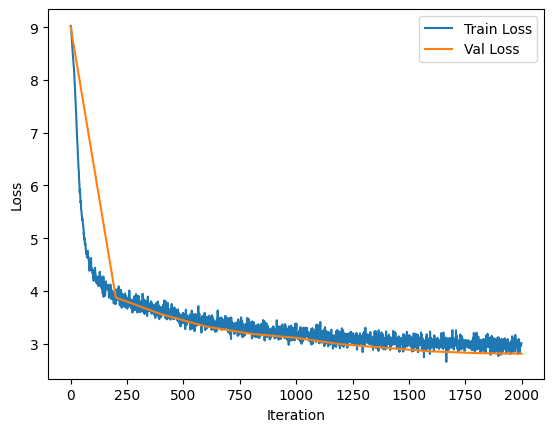

In [12]:
# plot
import matplotlib.pyplot as plt
plt.plot(losses)
plt.plot(np.linspace(0, len(losses), len(avg_val_losses)), avg_val_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()
# Save the model
torch.save(model.state_dict(), "gpt_model.pth")

In [19]:
ckpt = torch.load("gpt_model.pth", map_location=device, weights_only=True)
loaded_model = GPT(
    vocab_size=vocab_size,
    d_model=192, num_heads=4, n_layer=4, d_ff=512, dropout=0.1, max_seq_len=block_size
).to(device)
loaded_model.load_state_dict(ckpt)
loaded_model.eval()

prompt = "Once upon a time,"
prompt_tokens = tokenizer.encode(prompt).ids

print(f"\nPrompt: {prompt!r}")
print("Generated: ", end="", flush=True)
print(prompt, end="", flush=True)

for token in loaded_model.generate(
    prompt_tokens, max_tokens=150, temperature=0.8, top_k=50, seed=89754,
):
    print(tokenizer.decode([token]), end="", flush=True)
print()


Prompt: 'Once upon a time,'
Generated: Once upon a time, there was a little girl named Lily. She loved to watch the birds and seek with her friends, especially the trees. One day, Lily's mommy went to the park to play games and play in the garden.

Lily's mommy found a big puddle with a big rock. "Hi, I am Tom. You are very tall and green. We are very old." They wanted to help.

But Lily was too hard. She told her that she was not good for what happened. She gave him a big hug and said, "I love you."

Lily said, "I'm sorry, Lily. I'm glad you can see the bird. We will miss you."

The next day, Lily came back
